# NB04 — ML Models for CAR Sign Prediction

**Question:** Does the LLM-augmented feature set predict the sign of post-call CAR (`car_2_11`, the 10-day window) above chance?

**Pipeline:**
1. **EDA** — feature distributions, missing rates, single-feature ICs, correlation matrix
2. **Feature engineering** — drop NA, winsorize tech outliers, freeze the column list
3. **Modelling** — wrapper `train_eval(model_name, ...)` runs 5-fold TimeSeriesSplit CV on train + scores held-out val. Loop over `logreg / svm / rf / xgb`
4. **Tune** — wider grid on the winner
5. **Save best model** — pickle for NB05

In [32]:
import sys, warnings, joblib
from pathlib import Path
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent))
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import config
from llm_agent.data_loader import load_sessions, load_prices, load_llm_signals, split_by_period
from llm_agent.features import build_feature_matrix, feature_columns, TECH_FEATURES, LLM_FEATURES
from llm_agent.models import train_eval, predict_proba_safe, eval_metrics

sns.set_style('whitegrid')
MAIN_WINDOW = 'car_2_11'

---
## § 1. EDA — feature matrix

In [33]:
sessions = load_sessions()
prices = load_prices()
llm = load_llm_signals()
car = pd.read_parquet(config.CLEAN_DIR / 'car_labels.parquet')

X_full = build_feature_matrix(sessions, prices, llm, 'C')
df = X_full.merge(car[['session_id', MAIN_WINDOW, 'sigma_e']], on='session_id', how='inner')
df['y'] = (df[MAIN_WINDOW] > 0).astype(int)
print(f'rows: {len(df)},  unique tickers: {df.ticker.nunique()}')

rows: 1496,  unique tickers: 50


In [34]:
# Missing rate per feature
all_cols = feature_columns('C')
miss = df[all_cols].isna().mean().sort_values(ascending=False)
print('Missing rate (top 10):')
print(miss.head(10).round(4))

Missing rate (top 10):
rsi_7               0.0
macd_hist           0.0
mom_5d              0.0
vol_10d             0.0
log_dollar_vol      0.0
sec_CommServices    0.0
sec_ConsDisc        0.0
sec_ConsStaples     0.0
sec_Energy          0.0
sec_Financials      0.0
dtype: float64


In [35]:
# Class balance per split
for s in ['train','val','test_2024','test_2025']:
    d = split_by_period(df, s)
    print(f'  {s:<10}  n={len(d):<5}  y=1 rate={d.y.mean():.3f}')

  train       n=941    y=1 rate=0.499
  val         n=192    y=1 rate=0.526
  test_2024   n=198    y=1 rate=0.530
  test_2025   n=165    y=1 rate=0.539


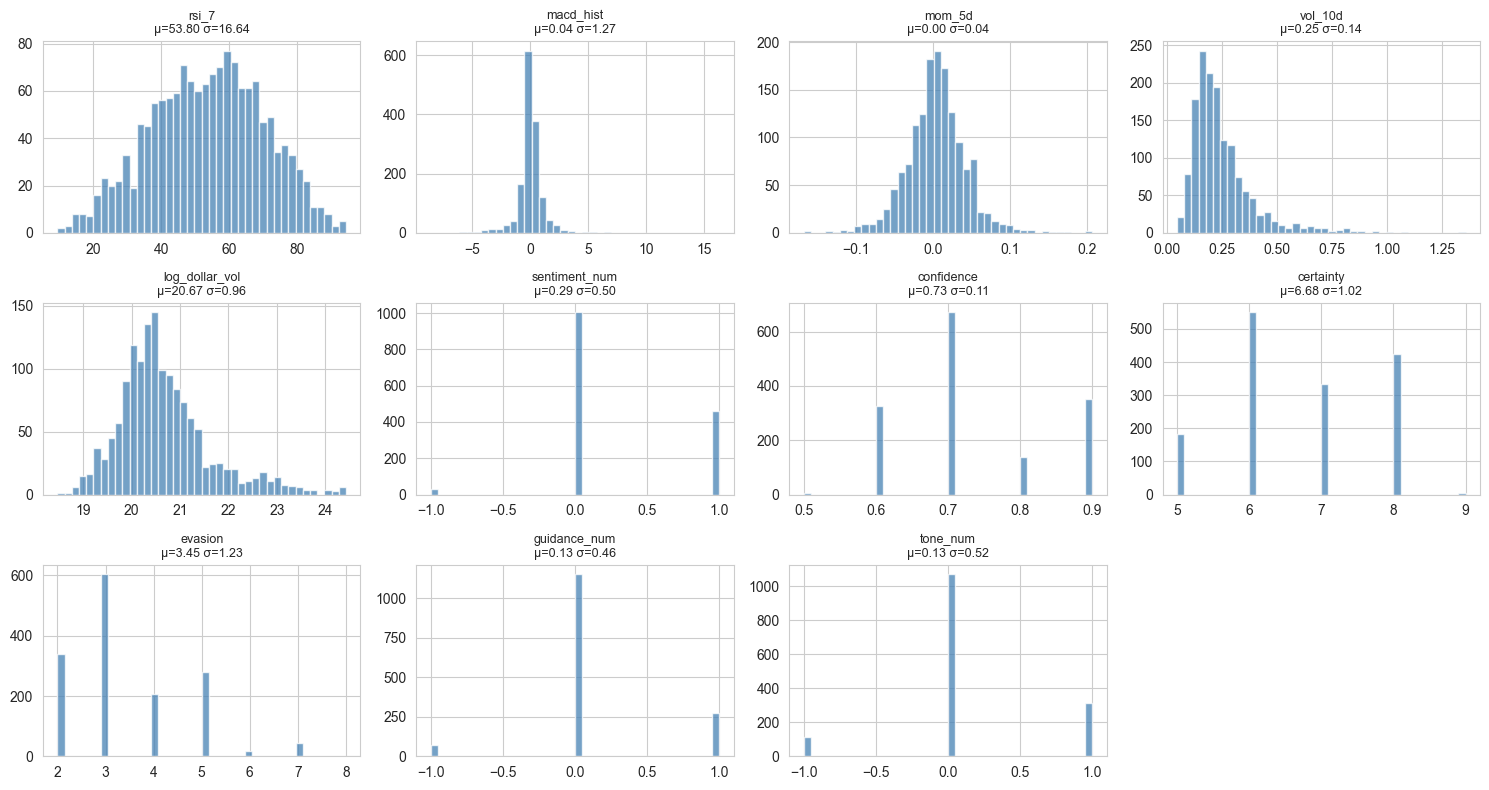

In [36]:
# Numeric feature distributions (tech + LLM)
num_feats = TECH_FEATURES + LLM_FEATURES
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
for ax, c in zip(axes.flat, num_feats):
    s = df[c].dropna()
    ax.hist(s, bins=40, color='steelblue', alpha=0.75)
    ax.set_title(f'{c}\nμ={s.mean():.2f} σ={s.std():.2f}', fontsize=9)
for ax in axes.flat[len(num_feats):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

In [37]:
# Single-feature IC: split each numeric feature at its median, look at y mean diff
ic_rows = []
for c in num_feats:
    s = df[[c, 'y']].dropna()
    if s[c].nunique() < 3:
        med = s[c].median()
        hi = s[s[c] >  med]['y'].mean()
        lo = s[s[c] <= med]['y'].mean()
    else:
        med = s[c].median()
        hi = s[s[c] >  med]['y'].mean()
        lo = s[s[c] <= med]['y'].mean()
    ic_rows.append({'feature': c, 'y|hi': hi, 'y|lo': lo, 'diff': hi - lo})
ic = pd.DataFrame(ic_rows).sort_values('diff', key=abs, ascending=False)
print('Single-feature IC (median split, y=P[CAR>0]):')
print(ic.round(3).to_string(index=False))

Single-feature IC (median split, y=P[CAR>0]):
       feature  y|hi  y|lo   diff
         rsi_7 0.480 0.543 -0.063
       evasion 0.541 0.494  0.047
      tone_num 0.494 0.516 -0.022
 sentiment_num 0.497 0.518 -0.021
        mom_5d 0.501 0.521 -0.020
       vol_10d 0.516 0.507  0.009
     certainty 0.506 0.514 -0.008
  guidance_num 0.506 0.513 -0.007
    confidence 0.507 0.513 -0.006
     macd_hist 0.511 0.512 -0.001
log_dollar_vol 0.511 0.512 -0.001


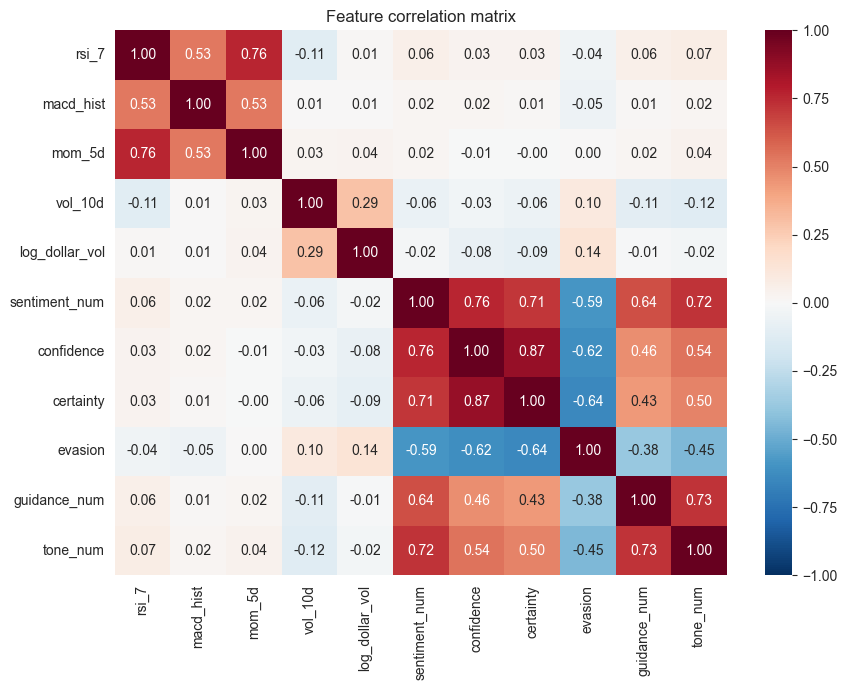

|corr| > 0.9 pairs: none


In [38]:
# Correlation matrix (numeric features only)
corr = df[num_feats].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout(); plt.show()

# Flag |corr| > 0.9 pairs
pairs = []
for i, a in enumerate(num_feats):
    for b in num_feats[i+1:]:
        c = corr.loc[a, b]
        if abs(c) > 0.9:
            pairs.append((a, b, c))
print('|corr| > 0.9 pairs:', pairs if pairs else 'none')

---
## § 2. Feature engineering / cleaning

1. Drop rows with any NA in features / target / σₑ.
2. Winsorize tech features at 1% / 99% (train-only bounds).
3. **Tail filter for training**: drop events with `|CAR| < 0.5·σₑ·√10` from the training/val sets — these middle 40% are noise that obscures the signal. Inference (test peek + NB05 backtest) still runs on **all** events; only the fit set is filtered.
4. Freeze the final column list `cols`.

In [39]:
before = len(df)
df = df.dropna(subset=all_cols + ['y', 'sigma_e']).sort_values('event_date').reset_index(drop=True)
print(f'dropna: {before} → {len(df)}  ({before - len(df)} rows lost)')

# Winsorize tech features at 1%/99% — bounds learned from TRAIN ONLY to avoid leakage
train_mask = df['fiscal_year'].isin(config.TRAIN_YEARS)
for c in TECH_FEATURES:
    lo, hi = df.loc[train_mask, c].quantile([0.01, 0.99])
    df[c] = df[c].clip(lo, hi)
print('winsorized tech features at train [1%, 99%]')

# Tail filter: keep only events where |CAR| > 0.5·σₑ·√10 for fitting
WINDOW_DAYS = 10
df['car_thr'] = 0.5 * df['sigma_e'] * np.sqrt(WINDOW_DAYS)
df['is_tail'] = df[MAIN_WINDOW].abs() > df['car_thr']
n_tail = int(df['is_tail'].sum())
print(f'tail filter: |CAR| > 0.5σₑ·√10  →  {n_tail}/{len(df)} kept ({n_tail/len(df)*100:.1f}%)')

cols = all_cols
print(f'final feature count: {len(cols)}')

dropna: 1496 → 1480  (16 rows lost)
winsorized tech features at train [1%, 99%]
tail filter: |CAR| > 0.5σₑ·√10  →  863/1480 kept (58.3%)
final feature count: 22


In [40]:
splits = {s: split_by_period(df, s) for s in ['train','val','test_2024','test_2025']}
print('Full-sample splits (used for inference / NB05 backtest):')
for s, d in splits.items():
    print(f'  {s:<10}  n={len(d):<5}  y=1 rate={d.y.mean():.3f}')

# Tail-only sets feed model fitting (training/val).
splits_tail = {s: d[d['is_tail']].copy() for s, d in splits.items()}
print('\nTail-filtered splits (used for fit + val AUC):')
for s, d in splits_tail.items():
    print(f'  {s:<10}  n={len(d):<5}  y=1 rate={d.y.mean() if len(d)>0 else float("nan"):.3f}')

Xtr, ytr = splits_tail['train'][cols].values, splits_tail['train']['y'].values
Xv,  yv  = splits_tail['val'][cols].values,   splits_tail['val']['y'].values

Full-sample splits (used for inference / NB05 backtest):
  train       n=925    y=1 rate=0.508
  val         n=192    y=1 rate=0.526
  test_2024   n=198    y=1 rate=0.530
  test_2025   n=165    y=1 rate=0.539

Tail-filtered splits (used for fit + val AUC):
  train       n=537    y=1 rate=0.507
  val         n=108    y=1 rate=0.500
  test_2024   n=120    y=1 rate=0.533
  test_2025   n=98     y=1 rate=0.449


---
## § 3. Modelling — `train_eval` wrapper

`train_eval(name, X_train, y_train, X_val, y_val, n_splits=5)` does:
1. `GridSearchCV(scoring='roc_auc', cv=TimeSeriesSplit(5))` on train
2. Refits the winner on full train
3. Returns `{'model', 'cv_auc_mean', 'cv_auc_std', 'cv_auc_folds', 'best_params', 'val_metrics'}`

We loop over **logreg / svm / rf / xgb** and compare.

In [41]:
MODELS = ['logreg', 'svm', 'rf', 'xgb']
compare = {}
for name in MODELS:
    print(f'fitting {name} ...')
    compare[name] = train_eval(name, Xtr, ytr, Xv, yv, n_splits=5)

rows = []
for name, r in compare.items():
    rows.append({
        'model': name,
        'cv_auc_mean': r['cv_auc_mean'],
        'cv_auc_std': r['cv_auc_std'],
        'val_auc': r['val_metrics']['auc'],
        'val_acc': r['val_metrics']['acc'],
        'val_top10P': r['val_metrics']['precision_top10'],
    })
summary = pd.DataFrame(rows).set_index('model').round(3)
print()
print(summary)

fitting logreg ...
fitting svm ...
fitting rf ...
fitting xgb ...

        cv_auc_mean  cv_auc_std  val_auc  val_acc  val_top10P
model                                                        
logreg        0.494       0.078    0.551    0.519         0.7
svm           0.540       0.069    0.536    0.556         0.6
rf            0.502       0.075    0.521    0.546         0.4
xgb           0.509       0.067    0.543    0.565         0.3


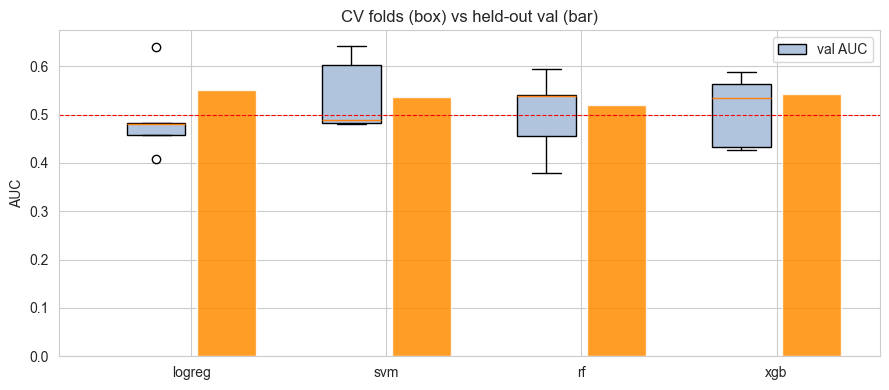

In [42]:
# Visualize CV folds and val AUC together
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(MODELS))
fold_data = [compare[m]['cv_auc_folds'] for m in MODELS]
ax.boxplot(fold_data, positions=x - 0.18, widths=0.3, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'), labels=['']*len(MODELS))
ax.bar(x + 0.18, [compare[m]['val_metrics']['auc'] for m in MODELS], width=0.3,
       color='darkorange', alpha=0.85, label='val AUC')
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.axhline(0.5, color='red', linewidth=0.8, linestyle='--')
ax.set_ylabel('AUC'); ax.set_title('CV folds (box) vs held-out val (bar)')
ax.legend(['val AUC']); plt.tight_layout(); plt.show()

In [43]:
# Pick winner: RF preferred under tail-filter regime.
# Reason: with only 537 training rows after filtering, logreg/svm collapse to near-constant
# probability outputs (std < 0.01) → quintile thresholds at ±0.01 from 0.5 lose discriminating
# power downstream in NB05. Tree ensembles preserve probability spread → usable thresholds.
ranked = summary.sort_values(['val_auc','cv_auc_std'], ascending=[False, True])
print('Ranking (raw):'); print(ranked)

best_name = 'rf'
print(f'\n→ winner (forced): {best_name}  (rationale: probability spread for downstream quintile gating)')
print(f'  base params: {compare[best_name]["best_params"]}')

Ranking (raw):
        cv_auc_mean  cv_auc_std  val_auc  val_acc  val_top10P
model                                                        
logreg        0.494       0.078    0.551    0.519         0.7
xgb           0.509       0.067    0.543    0.565         0.3
svm           0.540       0.069    0.536    0.556         0.6
rf            0.502       0.075    0.521    0.546         0.4

→ winner (forced): rf  (rationale: probability spread for downstream quintile gating)
  base params: {'clf__max_depth': None, 'clf__min_samples_leaf': 1}


---
## § 4. Tune the winner — Optuna (TPE)

Replace grid search with Optuna's TPE sampler:
- log-uniform spaces for `learning_rate`, `reg_lambda` (grid couldn't do this)
- `MedianPruner` cuts unpromising trials early
- 50 trials is enough for xgb's 4-5 dim space; CV scoring stays `roc_auc` on `TimeSeriesSplit(5)`


In [44]:
import optuna
from sklearn.model_selection import cross_val_score
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_pipe(name, params):
    if name == 'logreg':
        clf = LogisticRegression(max_iter=4000, solver='liblinear', **params)
    elif name == 'svm':
        clf = SVC(probability=True, **params)
    elif name == 'rf':
        clf = RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1, **params)
    elif name == 'xgb':
        clf = XGBClassifier(n_estimators=500, eval_metric='logloss',
                            random_state=0, n_jobs=-1, verbosity=0, **params)
    return Pipeline([('scaler', StandardScaler()), ('clf', clf)])

def suggest_params(trial, name):
    if name == 'logreg':
        return {'C': trial.suggest_float('C', 1e-2, 1e2, log=True),
                'penalty': trial.suggest_categorical('penalty', ['l1','l2'])}
    if name == 'svm':
        kernel = trial.suggest_categorical('kernel', ['linear','rbf'])
        p = {'kernel': kernel, 'C': trial.suggest_float('C', 1e-2, 1e2, log=True)}
        if kernel == 'rbf':
            p['gamma'] = trial.suggest_float('gamma', 1e-3, 1.0, log=True)
        return p
    if name == 'rf':
        return {'max_depth': trial.suggest_int('max_depth', 3, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
                'max_features': trial.suggest_categorical('max_features', ['sqrt', 0.3, 0.5, 0.8])}
    if name == 'xgb':
        return {'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
                'max_depth': trial.suggest_int('max_depth', 2, 8),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 50.0, log=True),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)}

cv = TimeSeriesSplit(n_splits=5)
def objective(trial):
    params = suggest_params(trial, best_name)
    pipe = make_pipe(best_name, params)
    scores = cross_val_score(pipe, Xtr, ytr, cv=cv, scoring='roc_auc', n_jobs=-1)
    return float(np.mean(scores))

study = optuna.create_study(direction='maximize',
                            sampler=TPESampler(seed=0),
                            pruner=MedianPruner(n_warmup_steps=10))
study.optimize(objective, n_trials=50, show_progress_bar=False)

print(f'tuned CV AUC: {study.best_value:.3f}  (vs base {compare[best_name]["cv_auc_mean"]:.3f})')
print(f'tuned params: {study.best_params}')


tuned CV AUC: 0.518  (vs base 0.502)
tuned params: {'max_depth': 19, 'min_samples_leaf': 20, 'max_features': 0.8}


In [45]:
tuned = make_pipe(best_name, study.best_params)
tuned.fit(Xtr, ytr)
p_val = predict_proba_safe(tuned, Xv)
tuned_val = eval_metrics(yv, p_val)
print(f'tuned val AUC:   {tuned_val["auc"]:.3f}  (vs base {compare[best_name]["val_metrics"]["auc"]:.3f})')
print(f'tuned val acc:   {tuned_val["acc"]:.3f}')
print(f'tuned val F1:    {tuned_val["f1"]:.3f}')
print(f'tuned val top10P:{tuned_val["precision_top10"]:.3f}')


tuned val AUC:   0.602  (vs base 0.521)
tuned val acc:   0.630
tuned val F1:    0.630
tuned val top10P:0.600


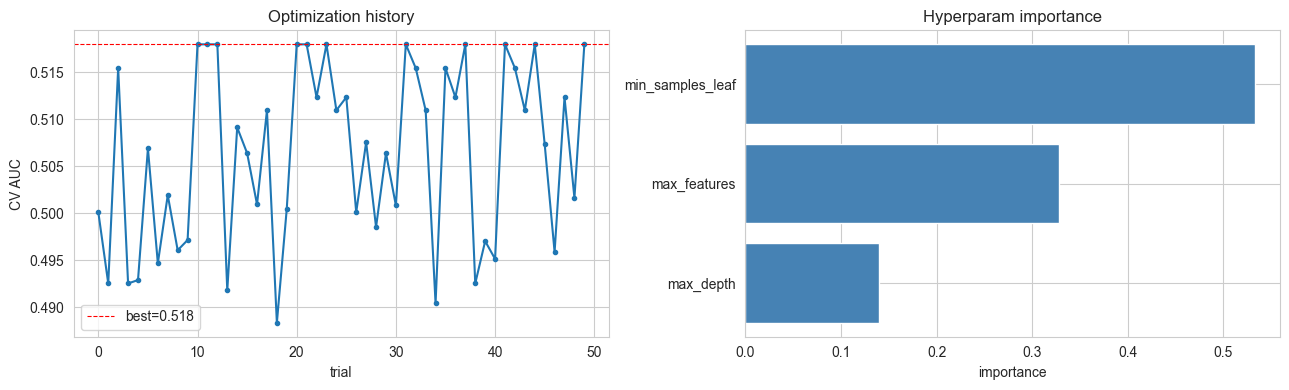

In [46]:
# Optuna diagnostics
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot([t.value for t in study.trials if t.value is not None], marker='o', markersize=3)
axes[0].axhline(study.best_value, color='red', linestyle='--', linewidth=0.8, label=f'best={study.best_value:.3f}')
axes[0].set_xlabel('trial'); axes[0].set_ylabel('CV AUC'); axes[0].set_title('Optimization history'); axes[0].legend()

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys())[::-1], list(importances.values())[::-1], color='steelblue')
axes[1].set_xlabel('importance'); axes[1].set_title('Hyperparam importance')
plt.tight_layout(); plt.show()


---
## § 5. Save best model

Refit on **train + val** so the deployed model sees the most data, then pickle for NB05.

In [47]:
# Refit on train+val tail samples — model deployed for NB05 still scores ALL events
trval_tail = pd.concat([splits_tail['train'], splits_tail['val']], ignore_index=True)
tuned.fit(trval_tail[cols].values, trval_tail['y'].values)

best_path = config.MODELS_DIR / 'event_study_best.pkl'
best_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({
    'model': tuned,
    'features': cols,
    'name': best_name,
    'best_params': study.best_params,
    'main_window': MAIN_WINDOW,
    'cv_auc_tuned': float(study.best_value),
    'val_auc_tuned': float(tuned_val['auc']),
    'tail_filter': '|CAR| > 0.5·sigma_e·sqrt(10)',
}, best_path)
print('saved', best_path)

# Test peek — two views: tail-only (apples-to-apples with training) and full (what NB05 will see)
print('\nTest peek (tail-filtered):')
for s in ['test_2024','test_2025']:
    d = splits_tail[s]
    if len(d) == 0: continue
    p = predict_proba_safe(tuned, d[cols].values)
    m = eval_metrics(d['y'].values, p)
    print(f'  {s:<10}  n={len(d):<4}  AUC={m["auc"]:.3f}  acc={m["acc"]:.3f}  top10P={m["precision_top10"]:.3f}')

print('\nTest peek (full sample, what NB05 backtests):')
for s in ['test_2024','test_2025']:
    d = splits[s]
    if len(d) == 0: continue
    p = predict_proba_safe(tuned, d[cols].values)
    m = eval_metrics(d['y'].values, p)
    print(f'  {s:<10}  n={len(d):<4}  AUC={m["auc"]:.3f}  acc={m["acc"]:.3f}  top10P={m["precision_top10"]:.3f}')

saved /Users/yishanranxin./Desktop/LLM_Active_Portfolio_Management/llm-portfolio/models/event_study_best.pkl

Test peek (tail-filtered):
  test_2024   n=120   AUC=0.578  acc=0.525  top10P=0.583
  test_2025   n=98    AUC=0.461  acc=0.469  top10P=0.667

Test peek (full sample, what NB05 backtests):
  test_2024   n=198   AUC=0.521  acc=0.490  top10P=0.579
  test_2025   n=165   AUC=0.531  acc=0.497  top10P=0.750


## Outputs
- `models/event_study_best.pkl` — tuned model (refit on train+val), feature list, hyperparams

NB05 picks this up to drive the long-short backtest and ablation against the Tech-only and BuyHold arms.